# Predicting Customer Churn Using Machine Learning

#### Student name(s)

**Student Name:** Jashwanth Patel Akula


## Abstract

Customer churn is an important business problem because retaining existing customers is often more valuable than acquiring new ones. This project investigates whether machine learning can predict whether a telecommunications customer will leave the company based on demographic characteristics, account information, services used, contract type, tenure, and billing information.

The experiment uses the IBM Telco Customer Churn dataset. The project begins with exploratory data analysis (EDA) to understand the structure of the data, identify missing or inconsistent values, examine the distribution of the target variable, and investigate relationships between customer characteristics and churn. The data is then prepared using appropriate numerical imputation, categorical encoding, and feature scaling.

Three supervised classification algorithms are developed using Python and scikit-learn: Logistic Regression, Decision Tree, and Random Forest. The models are evaluated using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and ROC curves. The models are compared to determine which approach provides the strongest predictive performance for customer churn.

The results demonstrate how predictive analytics can be used to identify customers who may be at greater risk of leaving a telecommunications service.

## Table of Content

[Problem](#problem)    
[Data Understanding](#data_understanding)    
[Data Preparation](#data_preparation)    
[Modeling](#modeling)    
[Evaluation](#evaluation)    
[References](#references)    

## Problem <a class="anchor" id="problem"></a>

Customer churn occurs when a customer stops using a company's services. In the telecommunications industry, identifying customers who are likely to churn can help a company take preventive actions such as improving customer service, offering appropriate plans, or providing retention incentives.

The main problem addressed in this project is:

> **Can customer demographic, service, contract, tenure, and billing information be used to predict whether a telecommunications customer will churn?**

The experiment addresses the following questions:

1. What characteristics are associated with customer churn?
2. Are there noticeable differences between customers who churn and customers who remain?
3. Can machine learning models accurately classify customers as likely to churn or not churn?
4. Which classification model provides the best overall predictive performance?
5. Which evaluation metrics are most useful for assessing a customer-churn model?

The target variable is **Churn**, where `Yes` indicates that the customer churned and `No` indicates that the customer did not churn.

## Data Understanding<a class="anchor" id="data_understanding"></a>

### Dataset

The project uses the **IBM Telco Customer Churn** dataset. The dataset contains information about customers of a telecommunications company. Variables describe customer demographics, subscribed services, account information, contract information, tenure, and charges.

The dataset contains approximately 7,000 customer records and includes variables describing:

- Customer identification
- Gender
- Senior citizen status
- Partner and dependents
- Tenure
- Phone service
- Internet service
- Online security
- Online backup
- Device protection
- Technical support
- Streaming services
- Contract type
- Paperless billing
- Payment method
- Monthly charges
- Total charges
- Churn status

The original `customerID` field is an identifier rather than a predictive customer characteristic, so it will not be used as a model feature.

### Data Source
The dataset was obtained from Kaggle and is publicly available as the Telco Customer Churn dataset. The dataset is based on the IBM Telco Customer Churn sample data.

The dataset was downloaded from Kaggle as a CSV file and is used locally in this Jupyter notebook. Keeping the CSV file with the notebook/project allows the experiment to be reproduced without depending on an external download during notebook execution.

Kaggle Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [1]:
# Import libraries used throughout the project

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully.
Number of rows: 7043
Number of columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Display the dataset structure

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Dataset information

In [5]:
# Display descriptive statistics

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [7]:
# Check missing values

missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values by column:")
display(missing_values.to_frame("Missing Values"))

Missing values by column:


,Missing Values
customerID,0
DeviceProtection,0
TotalCharges,0
MonthlyCharges,0
PaymentMethod,0
PaperlessBilling,0
Contract,0
StreamingMovies,0
StreamingTV,0
TechSupport,0


In [8]:
# Check unique values in important categorical columns

categorical_columns_to_inspect = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "Contract",
    "PaymentMethod",
    "Churn"
]

for column in categorical_columns_to_inspect:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

SeniorCitizen:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


### Exploratory Data Analysis

The exploratory data analysis examines the target variable and selected customer characteristics. Visualizations are used to identify patterns that may be useful for predicting churn.

The analysis focuses on:

- Churn distribution
- Contract type
- Internet service
- Payment method
- Customer tenure
- Monthly charges
- Total charges
- Relationships among numerical variables

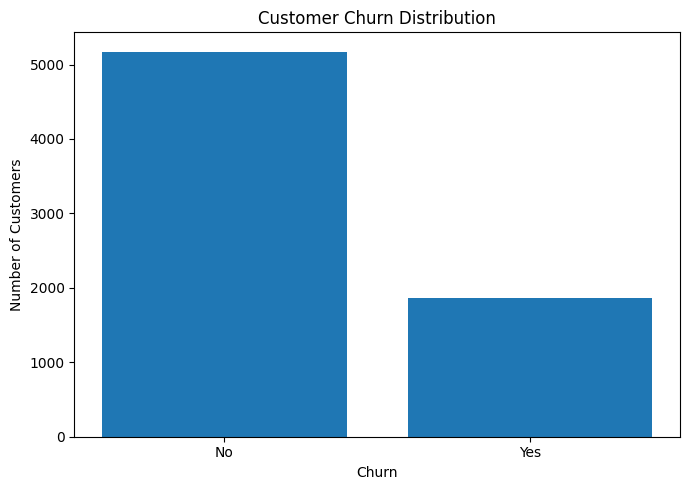

Churn percentages:
Churn
No     73.46
Yes    26.54
Name: count, dtype: float64


In [9]:
# Churn distribution

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print("Churn percentages:")
print((churn_counts / len(df) * 100).round(2))

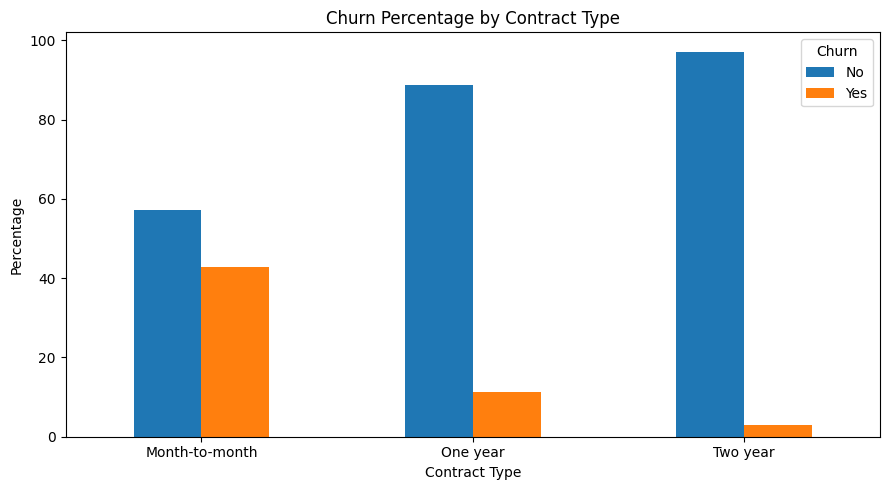

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [10]:
# Churn by contract type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

display(contract_churn.round(2))

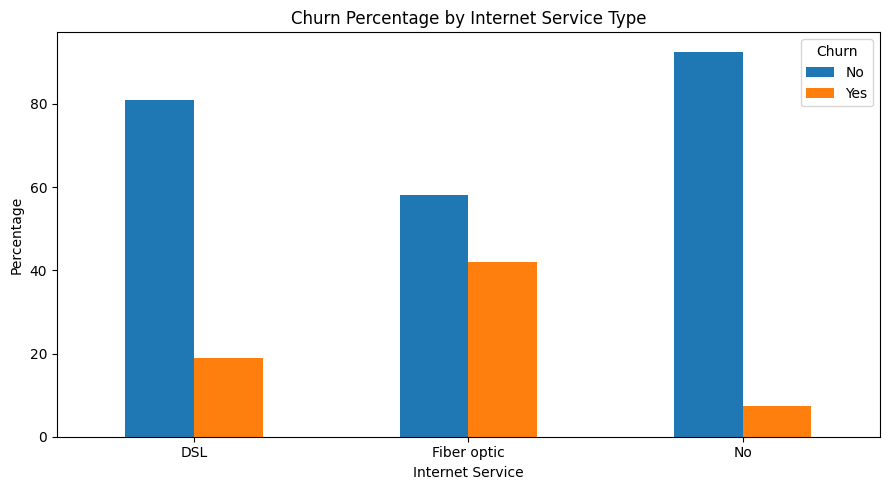

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [11]:
# Churn by internet service type

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Percentage by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

display(internet_churn.round(2))

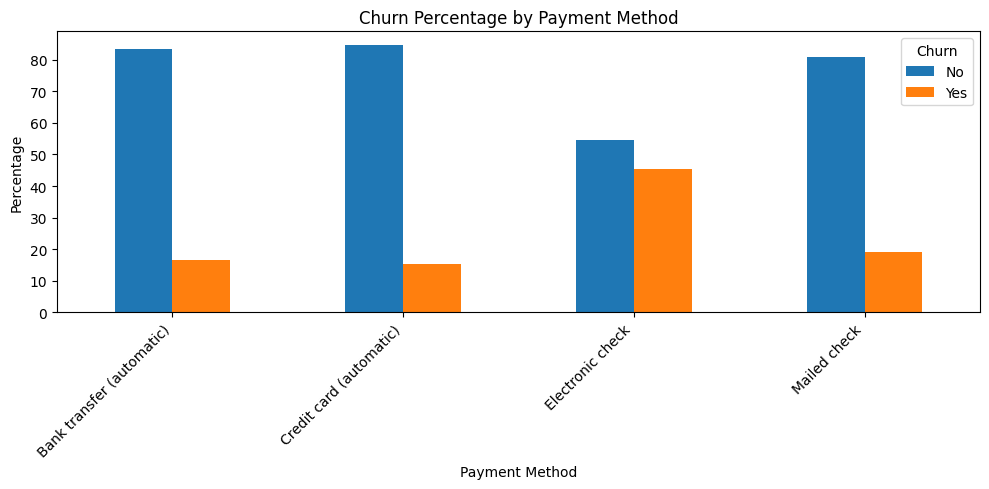

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [12]:
# Churn by payment method

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Percentage by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

display(payment_churn.round(2))

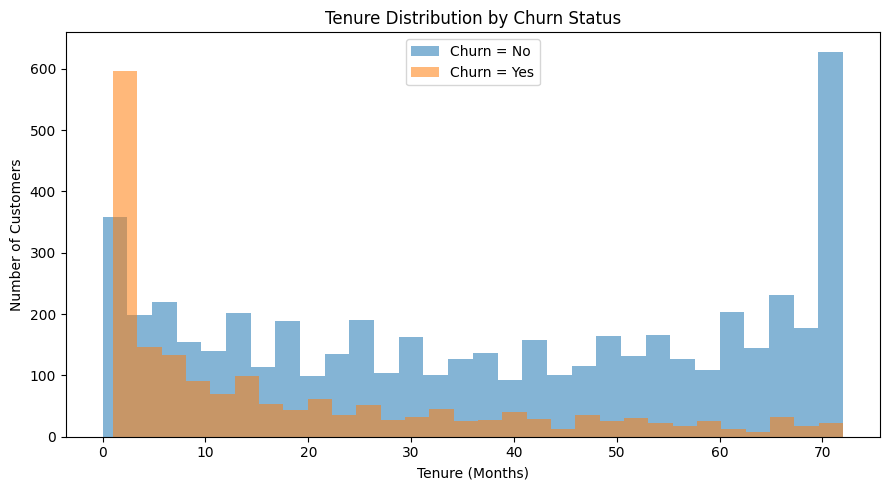

In [13]:
# Tenure distribution by churn status

plt.figure(figsize=(9, 5))

for churn_value in ["No", "Yes"]:
    subset = df.loc[df["Churn"] == churn_value, "tenure"]
    
    plt.hist(
        subset,
        bins=30,
        alpha=0.55,
        label=f"Churn = {churn_value}"
    )

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

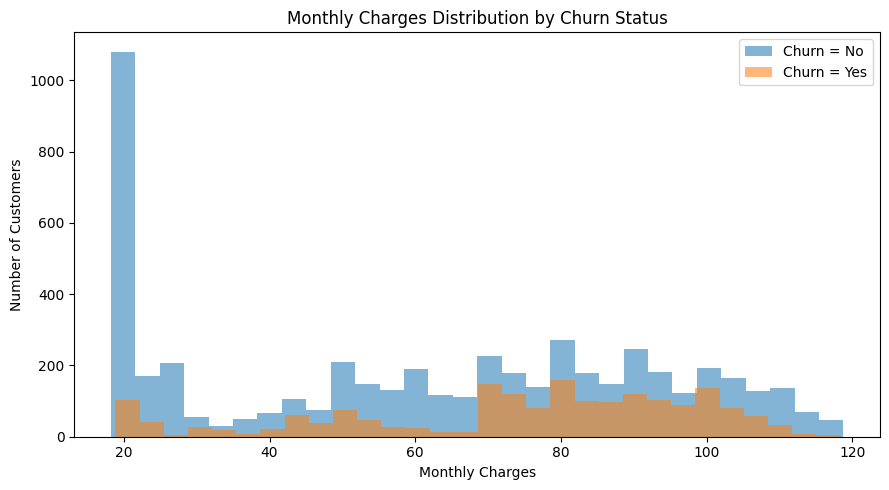

In [14]:
# Monthly charges distribution by churn status

plt.figure(figsize=(9, 5))

for churn_value in ["No", "Yes"]:
    subset = df.loc[df["Churn"] == churn_value, "MonthlyCharges"]
    
    plt.hist(
        subset,
        bins=30,
        alpha=0.55,
        label=f"Churn = {churn_value}"
    )

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

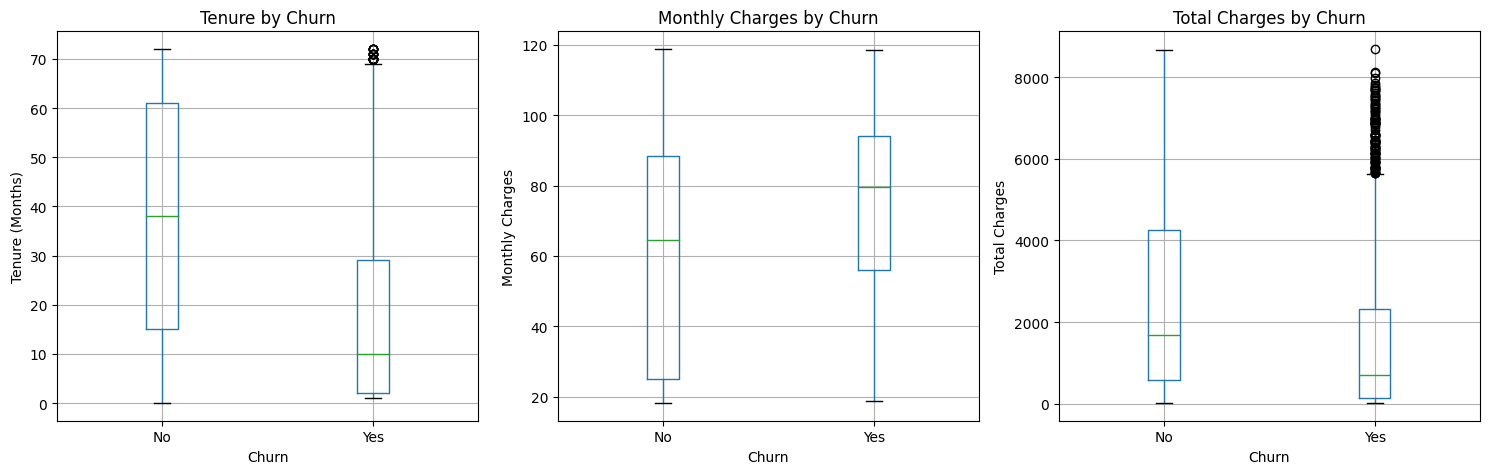

In [15]:
# Boxplots for important numerical variables by churn

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.boxplot(
    column="tenure",
    by="Churn",
    ax=axes[0]
)

axes[0].set_title("Tenure by Churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Tenure (Months)")


df.boxplot(
    column="MonthlyCharges",
    by="Churn",
    ax=axes[1]
)

axes[1].set_title("Monthly Charges by Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Monthly Charges")


# Convert TotalCharges to numeric for the visualization
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

temp_df = pd.DataFrame({
    "TotalCharges": total_charges_numeric,
    "Churn": df["Churn"]
})

temp_df.boxplot(
    column="TotalCharges",
    by="Churn",
    ax=axes[2]
)

axes[2].set_title("Total Charges by Churn")
axes[2].set_xlabel("Churn")
axes[2].set_ylabel("Total Charges")

plt.suptitle("")
plt.tight_layout()
plt.show()

Correlation matrix:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000,0.017,0.220,0.102
tenure,0.017,1.000,0.248,0.826
MonthlyCharges,0.220,0.248,1.000,0.651
TotalCharges,0.102,0.826,0.651,1.000


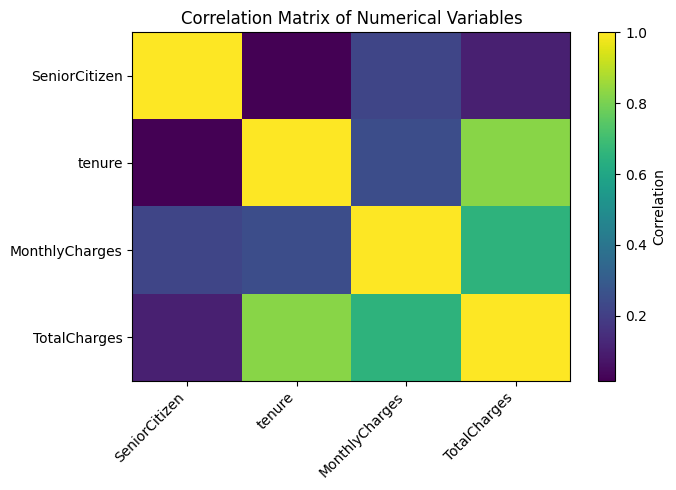

In [16]:
# Correlation analysis for numerical variables

numeric_for_corr = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
].copy()

numeric_for_corr["TotalCharges"] = pd.to_numeric(
    numeric_for_corr["TotalCharges"],
    errors="coerce"
)

correlation_matrix = numeric_for_corr.corr()

print("Correlation matrix:")
display(correlation_matrix.round(3))

plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### EDA Findings

The exploratory analysis provides several useful observations.

- The dataset contains more customers who did not churn than customers who churned.
- Contract type appears to have an important relationship with churn.
- Customers with shorter contracts generally show higher churn rates than customers with longer contracts.
- Customer tenure is related to churn, with newer customers generally showing greater churn risk.
- Monthly charges differ between customers who churn and customers who remain.
- Internet service type and payment method also show differences in churn percentages.
- These observations suggest that customer service, contract, tenure, and billing variables can provide useful information for churn prediction.

The EDA therefore supports the use of these variables in supervised classification models.

## Data Preparation<a class="anchor" id="data_preparation"></a>

The following data preparation steps will be performed:

1. Remove the `customerID` identifier because it does not represent a meaningful customer characteristic.
2. Convert `TotalCharges` from text to numeric values.
3. Separate the target variable `Churn` from the predictor variables.
4. Convert the target variable from `Yes` and `No` into binary values.
5. Identify numerical and categorical predictor variables.
6. Handle missing numerical values using median imputation.
7. Handle missing categorical values using the most frequent category.
8. Standardize numerical features.
9. Apply one-hot encoding to categorical features.
10. Split the data into training and testing sets.

A `ColumnTransformer` and `Pipeline` from scikit-learn are used to ensure that the preprocessing steps are applied consistently and that information from the testing dataset does not leak into the training process.

In [17]:
# Create a working copy

data = df.copy()

# Remove customer identifier
data = data.drop(columns=["customerID"])

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

print("Dataset shape after removing customerID:", data.shape)

print("\nMissing values after converting TotalCharges:")

missing_after_conversion = data.isnull().sum()

display(
    missing_after_conversion[
        missing_after_conversion > 0
    ].to_frame("Missing Values")
)

Dataset shape after removing customerID: (7043, 20)

Missing values after converting TotalCharges:


,Missing Values
TotalCharges,11


In [18]:
# Separate features and target

X = data.drop(columns=["Churn"])

y = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

Feature matrix shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target proportions:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [19]:
# Identify numerical and categorical columns

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical features: 4
Number of categorical features: 15


In [20]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

print("\nTraining target distribution:")
print(
    y_train.value_counts(normalize=True).round(3)
)

print("\nTesting target distribution:")
print(
    y_test.value_counts(normalize=True).round(3)
)

Training observations: 5634
Testing observations: 1409

Training target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [21]:
# Build preprocessing pipeline

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Modeling<a class="anchor" id="modeling"></a>

Three supervised classification algorithms will be used.

### Logistic Regression

Logistic Regression is selected as a baseline classification model because it is simple, interpretable, and appropriate for binary classification. It also provides probability estimates that can be used to calculate ROC-AUC.

### Decision Tree

A Decision Tree is selected because it can capture nonlinear relationships and interactions between customer characteristics. It is also relatively easy to interpret.

### Random Forest

Random Forest is selected because it combines multiple decision trees and can provide strong performance on structured tabular data. It can capture nonlinear relationships while reducing some of the overfitting associated with an individual decision tree.

The following parameters are used:

**Logistic Regression**
- `max_iter=2000`
- `random_state=42`

**Decision Tree**
- `max_depth=6`
- `min_samples_split=10`
- `random_state=42`

**Random Forest**
- `n_estimators=300`
- `max_depth=10`
- `min_samples_split=5`
- `random_state=42`
- `n_jobs=-1`

All models use the same preprocessing pipeline so that their results can be compared fairly.

In [22]:
# Define machine learning models

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
}

print("Models defined successfully.")

for name in models:
    print("-", name)

Models defined successfully.
- Logistic Regression
- Decision Tree
- Random Forest


In [23]:
# Create complete preprocessing + modeling pipelines

pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

print("Model pipelines created successfully.")

Model pipelines created successfully.


In [24]:
# Train all models

for name, pipeline in pipelines.items():

    print(f"Training {name}...")

    pipeline.fit(
        X_train,
        y_train
    )

    print(f"{name} training completed.")

print("\nAll models trained successfully.")

Training Logistic Regression...
Logistic Regression training completed.
Training Decision Tree...
Decision Tree training completed.
Training Random Forest...
Random Forest training completed.

All models trained successfully.


## Evaluation<a class="anchor" id="evaluation"></a>

The models are evaluated using the held-out testing dataset.

The following evaluation metrics are used:

- **Accuracy:** The proportion of all predictions that are correct.
- **Precision:** The proportion of predicted churn customers who actually churned.
- **Recall:** The proportion of actual churn customers correctly identified by the model.
- **F1-Score:** The harmonic mean of precision and recall.
- **ROC-AUC:** Measures the model's ability to distinguish between churn and non-churn customers across classification thresholds.

For this project, recall is particularly important because failing to identify a customer who is going to churn may represent a missed opportunity for customer retention.

In [25]:
# Evaluate all models

results = []

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("Model comparison:")
display(results_df.round(4))

Model comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419
1,Random Forest,0.8013,0.6610,0.5160,0.5796,0.8387
2,Decision Tree,0.7913,0.6342,0.5053,0.5625,0.8351


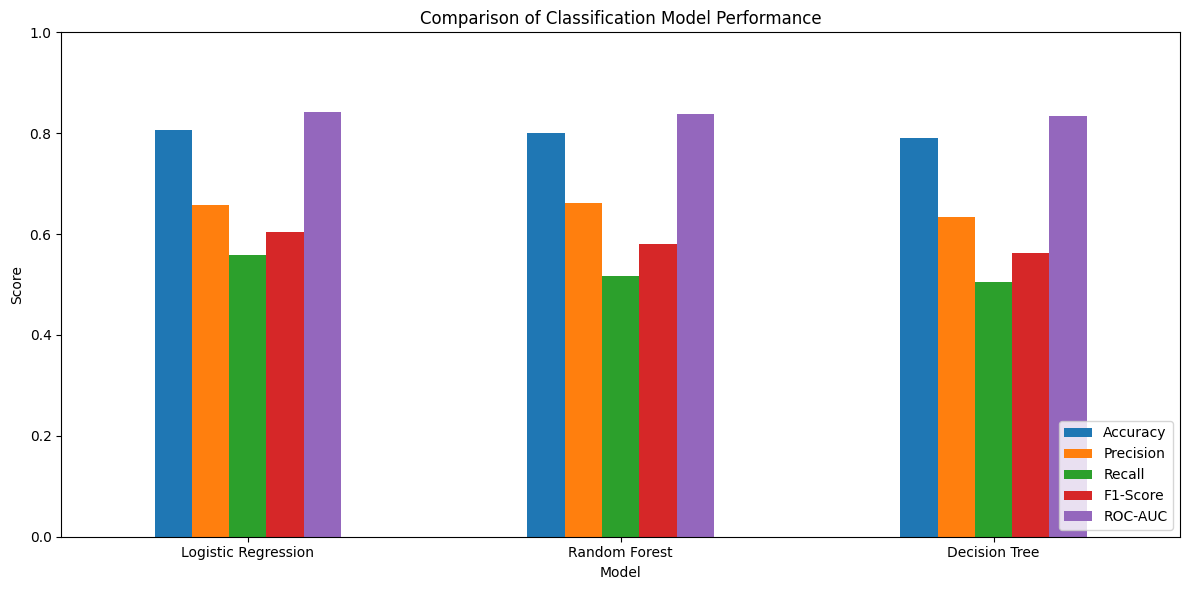

In [26]:
# Plot model performance comparison

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

plot_data = results_df.set_index(
    "Model"
)[metrics_to_plot]

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    "Comparison of Classification Model Performance"
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [27]:
# Display classification reports

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Churn",
                "Churn"
            ],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Random Forest
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79   

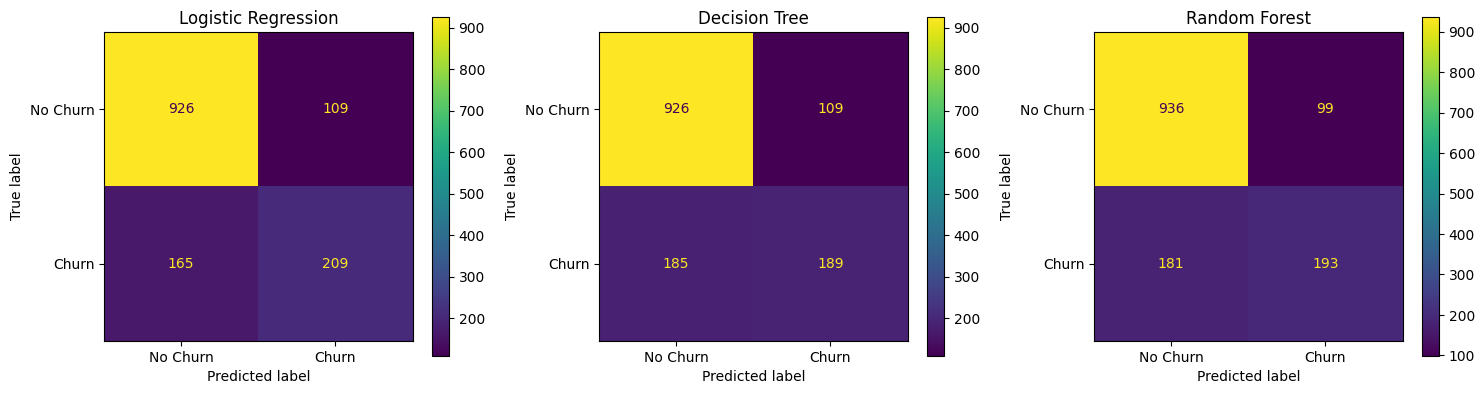

In [28]:
# Display confusion matrices

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for ax, (name, pipeline) in zip(
    axes,
    pipelines.items()
):

    y_pred = pipeline.predict(
        X_test
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "No Churn",
            "Churn"
        ]
    ).plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

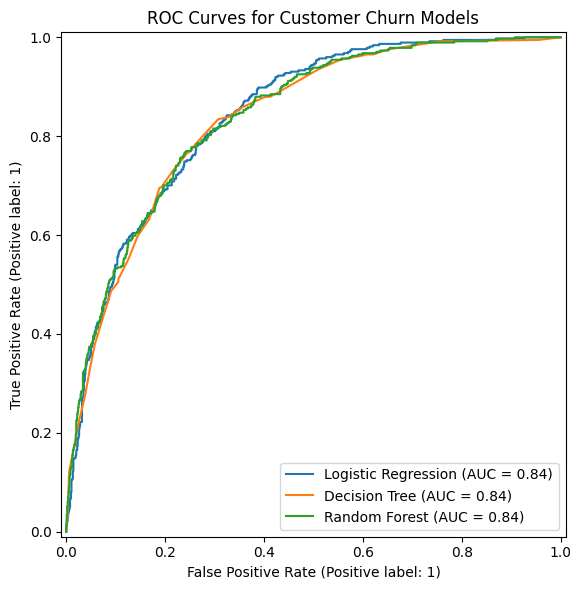

In [29]:
# Plot ROC curves

plt.figure(figsize=(9, 6))

for name, pipeline in pipelines.items():

    RocCurveDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        name=name,
        ax=plt.gca()
    )

plt.title(
    "ROC Curves for Customer Churn Models"
)

plt.tight_layout()
plt.show()

### Model Selection

The models are compared primarily using ROC-AUC because ROC-AUC measures the ability of a classifier to distinguish between customers who churn and customers who do not churn across different classification thresholds.

F1-score and recall are also considered because identifying customers who actually churn is important for a customer-retention strategy.

The model with the highest ROC-AUC will be selected as the best overall model for this experiment.

In [30]:
# Identify the best model based on ROC-AUC

best_model_name = results_df.iloc[0]["Model"]

best_model = pipelines[best_model_name]

print(
    "Best model based on ROC-AUC:",
    best_model_name
)

best_row = results_df.iloc[0]

print("\nBest model performance:")

display(
    pd.DataFrame([best_row]).round(4)
)

Best model based on ROC-AUC: Logistic Regression

Best model performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.604,0.8419


In [31]:
# Detailed evaluation of the selected model

best_predictions = best_model.predict(
    X_test
)

best_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

print(
    "Selected model:",
    best_model_name
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        best_predictions
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ],
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            best_probabilities
        ),
        4
    )
)

Selected model: Logistic Regression

Confusion Matrix:
[[926 109]
 [165 209]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8419


### Interpretation of Results

The model comparison table and charts provide a direct comparison of the three classification approaches.

The model with the highest ROC-AUC is selected as the best overall model for this experiment. Accuracy, precision, recall, and F1-score are also considered when interpreting model performance.

For a customer churn application, recall is particularly important because a false negative means that a customer who actually churns was classified as a customer who would remain. Such an error could result in a missed opportunity for customer retention.

Precision is also important because a low precision value means that many customers identified as churn risks may not actually churn. Contacting too many customers unnecessarily could increase the cost of retention campaigns.

Therefore, the final model should be selected by considering multiple evaluation metrics rather than accuracy alone.

The numerical results printed above should be used as the final reported model performance after all notebook cells have been executed.

### Limitations

This experiment has several limitations.

1. The dataset represents a particular telecommunications customer population and may not generalize to every telecommunications company.

2. Historical customer information does not guarantee future customer behavior.

3. The dataset does not include every possible factor that can influence churn, such as competitor offers, customer-service interactions, changes in customer circumstances, or economic conditions.

4. False positives and false negatives have different business costs, but this project does not assign explicit financial costs to each type of prediction error.

5. The models identify statistical relationships in the available data and should not be interpreted as proof that a particular customer characteristic directly causes churn.

6. Customer information should be handled responsibly with appropriate privacy, security, and fairness controls.

7. Model performance may change when the model is applied to a different telecommunications company or to future customer populations.

## References <a class="anchor" id="references"></a>

1. IBM. *Telco Customer Churn Dataset*. IBM sample dataset.

2. IBM. *Telco Customer Churn Sample Data*. Public educational dataset used for customer churn analysis.

3. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

4. Scikit-learn Developers. *Scikit-learn User Guide*. Documentation for preprocessing, pipelines, classification algorithms, model evaluation, confusion matrices, and ROC curves.

All code in this notebook was developed for this course project and should be executed from beginning to end before submission.